### Setup

In [147]:
import numba
import requests
import numpy as np
from io import BytesIO
from collections import namedtuple

CondensedTree = namedtuple(
    "CondensedTree", ["parent", "child", "lambda_val", "child_size"]
)

In [3]:
from fast_hdbscan.hdbscan import compute_minimum_spanning_tree, mst_to_linkage_tree


def linkage_hierarchy(data, min_samples):
    """Compute linkage hierarchy"""
    minimum_spanning_tree, _, _ = compute_minimum_spanning_tree(
        data, min_samples=min_samples
    )
    minimum_spanning_tree = minimum_spanning_tree[
        np.argsort(minimum_spanning_tree.T[2])
    ]
    linkage_tree = mst_to_linkage_tree(minimum_spanning_tree)
    return minimum_spanning_tree, linkage_tree

In [4]:
data = np.load(
    BytesIO(
        requests.get(
            "https://github.com/scikit-learn-contrib/hdbscan/blob/master/notebooks/clusterable_data.npy?raw=true"
        ).content
    )
)

In [5]:
mst, linkage = linkage_hierarchy(data, min_samples=10)

### Default

Creates new arrays with re-numbered and density-sorted edges.

- Single core
- Backwards iteration
- BF branch elimination

In [6]:
@numba.njit(
    fastmath=True,
    error_model="numpy",
    locals={"left": numba.int64, "right": numba.int64},
)
def condense_tree(
    hierarchy, min_cluster_size=10, max_cluster_size=np.inf, sample_weights=None
):
    root = 2 * hierarchy.shape[0]
    num_points = hierarchy.shape[0] + 1
    next_label = num_points + 1

    ignore = np.zeros(root + 1, dtype=np.bool_)
    relabel = np.zeros(root + 1, dtype=np.int64)
    relabel[root] = num_points

    parents = np.ones(root, dtype=np.int64)
    children = np.empty(root, dtype=np.int64)
    lambdas = np.empty(root, dtype=np.float32)
    sizes = np.ones(root, dtype=np.float32)

    if sample_weights is None:
        sample_weights = np.ones(num_points, dtype=np.float32)

    idx = 0
    for node in range(root, num_points - 1, -1):
        if ignore[node]:
            continue

        parent_node = relabel[node]
        left, right, d, _ = hierarchy[node - num_points]
        lambda_value = 1.0 / d

        left_count = (
            np.float32(hierarchy[left - num_points, 3])
            if left >= num_points
            else sample_weights[left]
        )
        right_count = (
            np.float32(hierarchy[right - num_points, 3])
            if right >= num_points
            else sample_weights[right]
        )

        # The logic here is in a strange order, but it has non-trivial
        # performance gains ... The most common case by far is a singleton on
        # the right; and cluster on the left take care of this separately
        if right < num_points and left_count >= min_cluster_size:
            relabel[left] = parent_node
            parents[idx] = parent_node
            children[idx] = right
            lambdas[idx] = lambda_value
            idx += 1
        # Next most common is a small left cluster and a large right cluster:
        # relabel the right node; eliminate the left branch
        elif left_count < min_cluster_size and right_count >= min_cluster_size:
            relabel[right] = parent_node
            idx = eliminate_branch(
                left,
                parent_node,
                lambda_value,
                parents,
                children,
                lambdas,
                idx,
                ignore,
                hierarchy,
                num_points,
            )
        # Then we have a large left cluster and a small right cluster: relabel
        # the left node; eliminate the right branch
        elif left_count >= min_cluster_size and right_count < min_cluster_size:
            relabel[left] = parent_node
            idx = eliminate_branch(
                right,
                parent_node,
                lambda_value,
                parents,
                children,
                lambdas,
                idx,
                ignore,
                hierarchy,
                num_points,
            )
        # If both clusters are small then eliminate all branches
        elif left_count < min_cluster_size and right_count < min_cluster_size:
            idx = eliminate_branch(
                left,
                parent_node,
                lambda_value,
                parents,
                children,
                lambdas,
                idx,
                ignore,
                hierarchy,
                num_points,
            )
            idx = eliminate_branch(
                right,
                parent_node,
                lambda_value,
                parents,
                children,
                lambdas,
                idx,
                ignore,
                hierarchy,
                num_points,
            )
        # If both clusters are too large then relabel both
        elif left_count > max_cluster_size and right_count > max_cluster_size:
            relabel[left] = parent_node
            relabel[right] = parent_node
        else:
            relabel[left] = next_label

            parents[idx] = parent_node
            children[idx] = next_label
            lambdas[idx] = lambda_value
            sizes[idx] = left_count
            next_label += 1
            idx += 1

            relabel[right] = next_label

            parents[idx] = parent_node
            children[idx] = next_label
            lambdas[idx] = lambda_value
            sizes[idx] = right_count
            next_label += 1
            idx += 1

    return CondensedTree(parents[:idx], children[:idx], lambdas[:idx], sizes[:idx]), relabel


@numba.njit()
def eliminate_branch(
    branch_node,
    parent_node,
    lambda_value,
    parents,
    children,
    lambdas,
    idx,
    ignore,
    hierarchy,
    num_points,
):
    if branch_node < num_points:
        parents[idx] = parent_node
        children[idx] = branch_node
        lambdas[idx] = lambda_value
        idx += 1
    else:
        for sub_node in bfs_from_hierarchy(hierarchy, branch_node, num_points):
            if sub_node < num_points:
                children[idx] = sub_node
                parents[idx] = parent_node
                lambdas[idx] = lambda_value
                idx += 1
            else:
                ignore[sub_node] = True

    return idx


@numba.njit()
def bfs_from_hierarchy(hierarchy, bfs_root, num_points):
    to_process = [bfs_root]
    result = []

    while to_process:
        result.extend(to_process)
        next_to_process = []
        for n in to_process:
            if n >= num_points:
                i = n - num_points
                next_to_process.append(int(hierarchy[i, 0]))
                next_to_process.append(int(hierarchy[i, 1]))
        to_process = next_to_process

    return result

In [7]:
ct, relabel = condense_tree(linkage, min_cluster_size=10)

In [8]:
%%timeit 
condense_tree(linkage, min_cluster_size=10)

59.5 µs ± 21.2 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


<Axes: ylabel='$\\lambda$ value'>

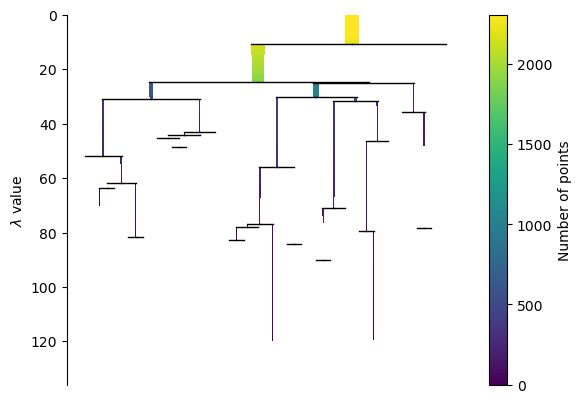

In [168]:
from hdbscan.plots import CondensedTree as PlotTree
from fast_hdbscan.hdbscan import to_numpy_rec_array

PlotTree(to_numpy_rec_array(ct), np.zeros(data.shape[0])).plot()

## Delay BF traversal

Creates new arrays with re-numbered and density-sorted edges. Avoid BF
traversal, instead track where points in eliminated branches should end up.

- Single core
- Full backwards iteration
- No BF branch elimination

In [165]:
@numba.njit(
    fastmath=True,
    error_model="numpy",
    locals={"left": numba.int64, "right": numba.int64},
)
def condense_tree_3(hierarchy, min_cluster_size=10, max_cluster_size=np.inf):
    # Indexing variables, root represents the last row in the hierarchy
    num_points = hierarchy.shape[0] + 1
    next_label = num_points + 1
    root = 2 * hierarchy.shape[0]
    num_points, next_label, root

    # Output arrays (shrink to fit after filling) 
    parents = np.empty(root, dtype=np.int64)
    children = np.empty(root, dtype=np.int64)
    lambdas = np.empty(root, dtype=np.float32)
    sizes = np.empty(root, dtype=np.float32)

    # tracks the new parent ID for hierarchy rows
    parent_of = np.empty(root - num_points + 1, dtype=np.int64)
    parent_of[root - num_points] = num_points

    # tracks the output index to put points from eliminated branches (per branch parent)
    pending_idx = np.empty(root - num_points + 1, dtype=np.int64)
    pending_lambda = np.empty(root - num_points + 1, dtype=np.float32)

    # Iterate through the hierarchy in reverse order
    idx = 0
    for node in range(root, num_points - 1, -1):
        # Extract the row
        node_idx = node - num_points
        parent_node = parent_of[node_idx]
        left, right, d, s = hierarchy[node_idx]

        # Extract child sizes
        is_pt_left = left < num_points
        is_pt_right = right < num_points
        left_size = np.int64(hierarchy[left - num_points, 3] if not is_pt_left else 1)
        right_size = np.int64(hierarchy[right - num_points, 3] if not is_pt_right else 1)

        # Determine where to store potential points and update the relevant indices
        if s >= min_cluster_size:
            out_idx = idx
            lambda_value = 1.0 / d
            idx += (
                (left_size  < min_cluster_size) * left_size + 
                (right_size < min_cluster_size) * right_size
            )
        else:
            out_idx = pending_idx[node_idx]
            lambda_value = pending_lambda[node_idx]

        # Store row or update parent depending on if left is a point
        if is_pt_left:
            parents[out_idx] = parent_node
            children[out_idx] = left
            lambdas[out_idx] = lambda_value
            sizes[out_idx] = 1.0
            out_idx += 1
        else:
            parent_of[left - num_points] = parent_node
            if left_size < min_cluster_size:
                pending_idx[left - num_points] = out_idx
                pending_lambda[left - num_points] = lambda_value
                out_idx += left_size

        # Store row or update parent depending on if right is a point
        if is_pt_right:
            parents[out_idx] = parent_node
            children[out_idx] = right
            lambdas[out_idx] = lambda_value
            sizes[out_idx] = 1.0
        else:
            parent_of[right - num_points] = parent_node
            if right_size < min_cluster_size:
                pending_idx[right - num_points] = out_idx
                pending_lambda[right - num_points] = lambda_value

        # If both clusters are too large, skip this merge
        if left_size > max_cluster_size and right_size > max_cluster_size:
            continue

        # If both sides are large enough, store this merge
        if left_size >= min_cluster_size and right_size >= min_cluster_size:
            parent_of[left - num_points] = next_label
            parents[idx] = parent_node
            children[idx] = next_label
            lambdas[idx] = lambda_value
            sizes[idx] = left_size
            next_label += 1
            idx += 1
            
            parent_of[right - num_points] = next_label
            parents[idx] = parent_node
            children[idx] = next_label
            lambdas[idx] = lambda_value
            sizes[idx] = right_size
            next_label += 1
            idx += 1

    return CondensedTree(parents[:idx], children[:idx], lambdas[:idx], sizes[:idx])

In [166]:
dct = condense_tree_3(linkage, min_cluster_size=10)

In [167]:
%%timeit 
condense_tree_3(linkage, min_cluster_size=10)

12.6 µs ± 9.47 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


<Axes: ylabel='$\\lambda$ value'>

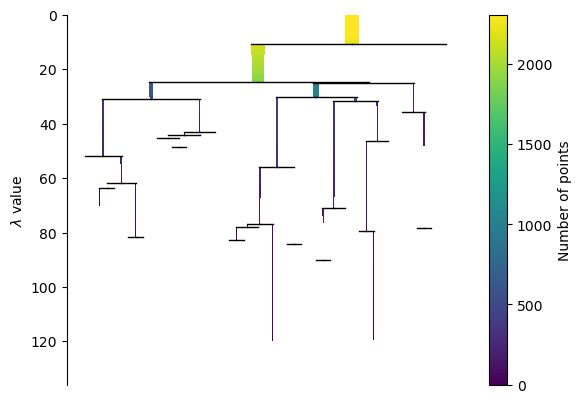

In [169]:
PlotTree(to_numpy_rec_array(dct), np.zeros(data.shape[0])).plot()

## Check equality

In [178]:
dir_ct = {pt: set() for pt in range(data.shape[0], 2 * linkage.shape[0] + 1)}
for pt, cd in zip(ct.parent, ct.child):
    dir_ct[pt].add(cd)

dir_dct = {pt: set() for pt in range(data.shape[0], 2 * linkage.shape[0] + 1)}
for pt, cd in zip(dct.parent, dct.child):
    dir_dct[pt].add(cd)

dir_dct == dir_ct,\
np.all(ct.parent == dct.parent),\
np.all(ct.lambda_val == dct.lambda_val),\
np.all(ct.child_size == dct.child_size)

(True, np.True_, np.True_, np.True_)